In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pickle
import bidsio
import sys
sys.path.append('../')
from helpers import *
from bandlimited_signal import *


device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
seed = 0 
ID_VAL = 131
BIDS_LOADER = bidsio.BIDSLoader(data_entities=[{'subject': '',
                                              'session': '',
                                              'suffix': 'T1w',
                                              'space': 'MNI152NLin2009aSym'}],
                              target_entities=[],
                              data_derivatives_names=['ATLAS'],
                              batch_size=1,
                              root_dir='./atlas/data/test/')

filename = 'lego_400.npz'
if not os.path.exists(filename):
    !gdown --id 108jNfjPITTsTA0lE6Kpg7Ei53BUVL-4n # Lego

data = np.load(filename)
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]

images, val_images, test_images = np.split(images[...,:3], [100,107], axis=0)
poses, val_poses, test_poses = np.split(poses, [100,107], axis=0)

TEST_IDX = 10

In [ ]:
def load_gt(task_name, id_val):
    dimension, dataset = task_name.split('_')
    if dataset=='div2k':
        RES = 128
        image_pil = Image.open(f'./DIV2K/DIV2K_train_LR_x8/0{str(id_val)}x8.png')
        image = np.array(image_pil.convert('L').resize((RES, RES))) / 255.0 
    elif dataset == 'mri' and dimension == '2d':
        RES = 128
        tmp = BIDS_LOADER.load_sample(idx = id_val, data_only=True) / 255.0
        vol = resize(tmp, (1, RES, RES, RES))[0]
        slice_idx = 48
        image = vol[:, :, slice_idx]  # (RES, RES)
    elif dataset == 'mri' and dimension == '3d':
        RES = 64
        tmp = BIDS_LOADER.load_sample(idx = id_val, data_only=True) / 255.0
        vol = resize(tmp, (1, RES, RES, RES))[0]
        slice_idx = 24
        image = vol[:, :, slice_idx]  # (RES, RES)
    elif dataset=='dragon':
        RES = 64
        vol =  resize(Voxel_Fitting(dimension=3, length=RES, bandlimit=0.6, seed=id_val, super_resolution=False, sparse=True).signal, (RES, RES, RES))
        slice_idx = 32
        image = vol[:, :, slice_idx]
    elif dataset == 'nerf':
        image = test_images[TEST_IDX,...]
    else:
        raise ValueError(f"Dataset {dataset} not supported.")
    return image

def plot_error_heatmaps_fig(task_name):
    gt = load_gt(task_name, ID_VAL)
    if task_name == '3d_dragon': gt = np.rot90(gt, 1, axes=(0, 1))
    model_name_dict = {'grid': 'Grid', 'ffn': 'FFN', 'ingp': 'Instant-NGP', 'gap': 'GA-Planes'}
    models = ['grid', 'ffn', 'ingp', 'gap']
    # models = ['ffn']
    n_models = len(models)

    fig = plt.figure(figsize=(21, 4 * n_models + 0.5))
    gs = fig.add_gridspec(n_models, 5, wspace=0.01, hspace=0.02)

    row_heatmaps = []
    row_axes4 = []

    for row, model in enumerate(models):
        model_name = model_name_dict[model]
        with open(f"{task_name}/{model}.pkl", "rb") as f:
            outputs = pickle.load(f)

        small_param, large_param = list(outputs.keys())
        if task_name == '3d_nerf':
            small_pred = outputs[small_param]['best_pred'].reshape(gt.shape)
            large_pred = outputs[large_param]['best_pred'].reshape(gt.shape)
        else:
            small_pred = outputs[small_param].reshape(gt.shape)
            large_pred = outputs[large_param].reshape(gt.shape)
        
        if task_name == '3d_dragon':
            small_pred = np.rot90(small_pred, 1, axes=(0, 1))
            large_pred = np.rot90(large_pred, 1, axes=(0, 1))
        if task_name == '3d_nerf':
            cs_nerf = {'Grid': CS['Grid']/1.5, 'FFN': CS['FFN']*3, 'Instant-NGP': CS['Instant-NGP']*2.2, 'GA-Planes': CS['GA-Planes']*1.8}
            model_difference = np.abs(small_pred - large_pred) * cs_nerf[model_name]
        else:
            model_difference = np.abs(small_pred - large_pred) * CS[model_name]
        actual_error = np.abs(small_pred - gt)

        vmin = min(model_difference.min(), actual_error.min())
        vmax = max(model_difference.max(), actual_error.max())

        axes = [fig.add_subplot(gs[row, i]) for i in range(5)]

        axes[0].imshow(gt, cmap='gray', interpolation='nearest')
        axes[1].imshow(small_pred, cmap='gray', interpolation='nearest')
        axes[2].imshow(large_pred, cmap='gray', interpolation='nearest')
        axes[3].imshow(model_difference, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
        heatmap = axes[4].imshow(actual_error, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)

        row_heatmaps.append(heatmap)
        row_axes4.append(axes[4])

        if row == 0:
            titles = ['Ground Truth', 'Small Model Prediction',
                      'Large Model Prediction', 'Predicted Error',
                      'Actual Error']
            for i, t in enumerate(titles):
                axes[i].set_title(t, fontsize=20)

        for ax in axes:
            ax.axis('off')

        axes[0].text(-0.05, 0.5, model_name, va='center', ha='right',
                     rotation='vertical', fontsize=20, transform=axes[0].transAxes)

    fig.tight_layout(rect=[0.02, 0, 0.97, 1])
    plt.draw()

    for heatmap, ax4 in zip(row_heatmaps, row_axes4):
        pos = ax4.get_position()
        cax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.008, pos.height])
        fig.colorbar(heatmap, cax=cax)
        cax.tick_params(labelsize=16)
    fig.savefig(f"figures/{task_name}_heatmaps.pdf", bbox_inches='tight', dpi=150)
    plt.show()

/tmp/ipykernel_718139/2521769680.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0, 0.97, 1])


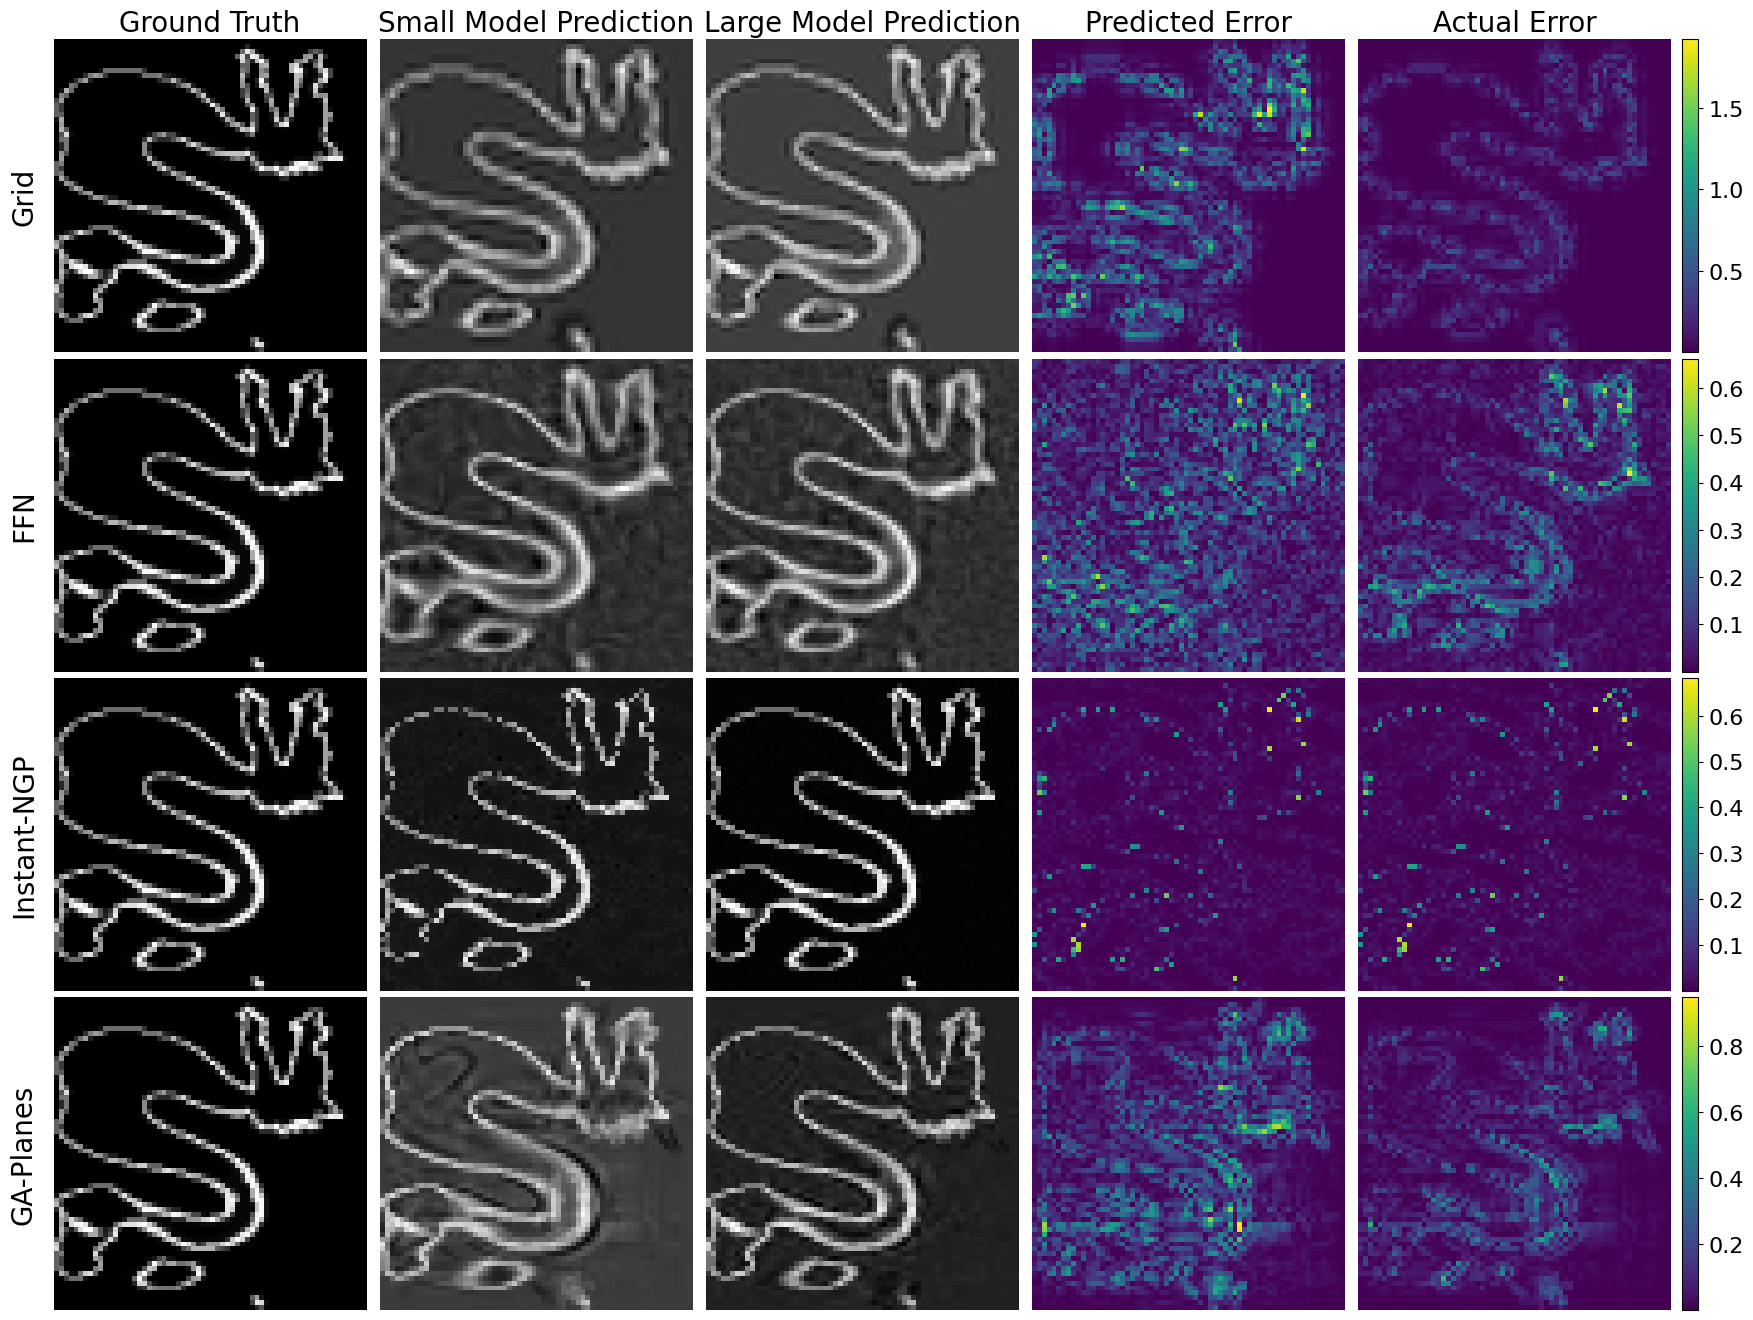

In [3]:
plot_error_heatmaps_fig('3d_dragon')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.9404352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8807175].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2772499].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3129338].
/tmp/ipykernel_4032445/2444206033.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0, 0.97, 1])


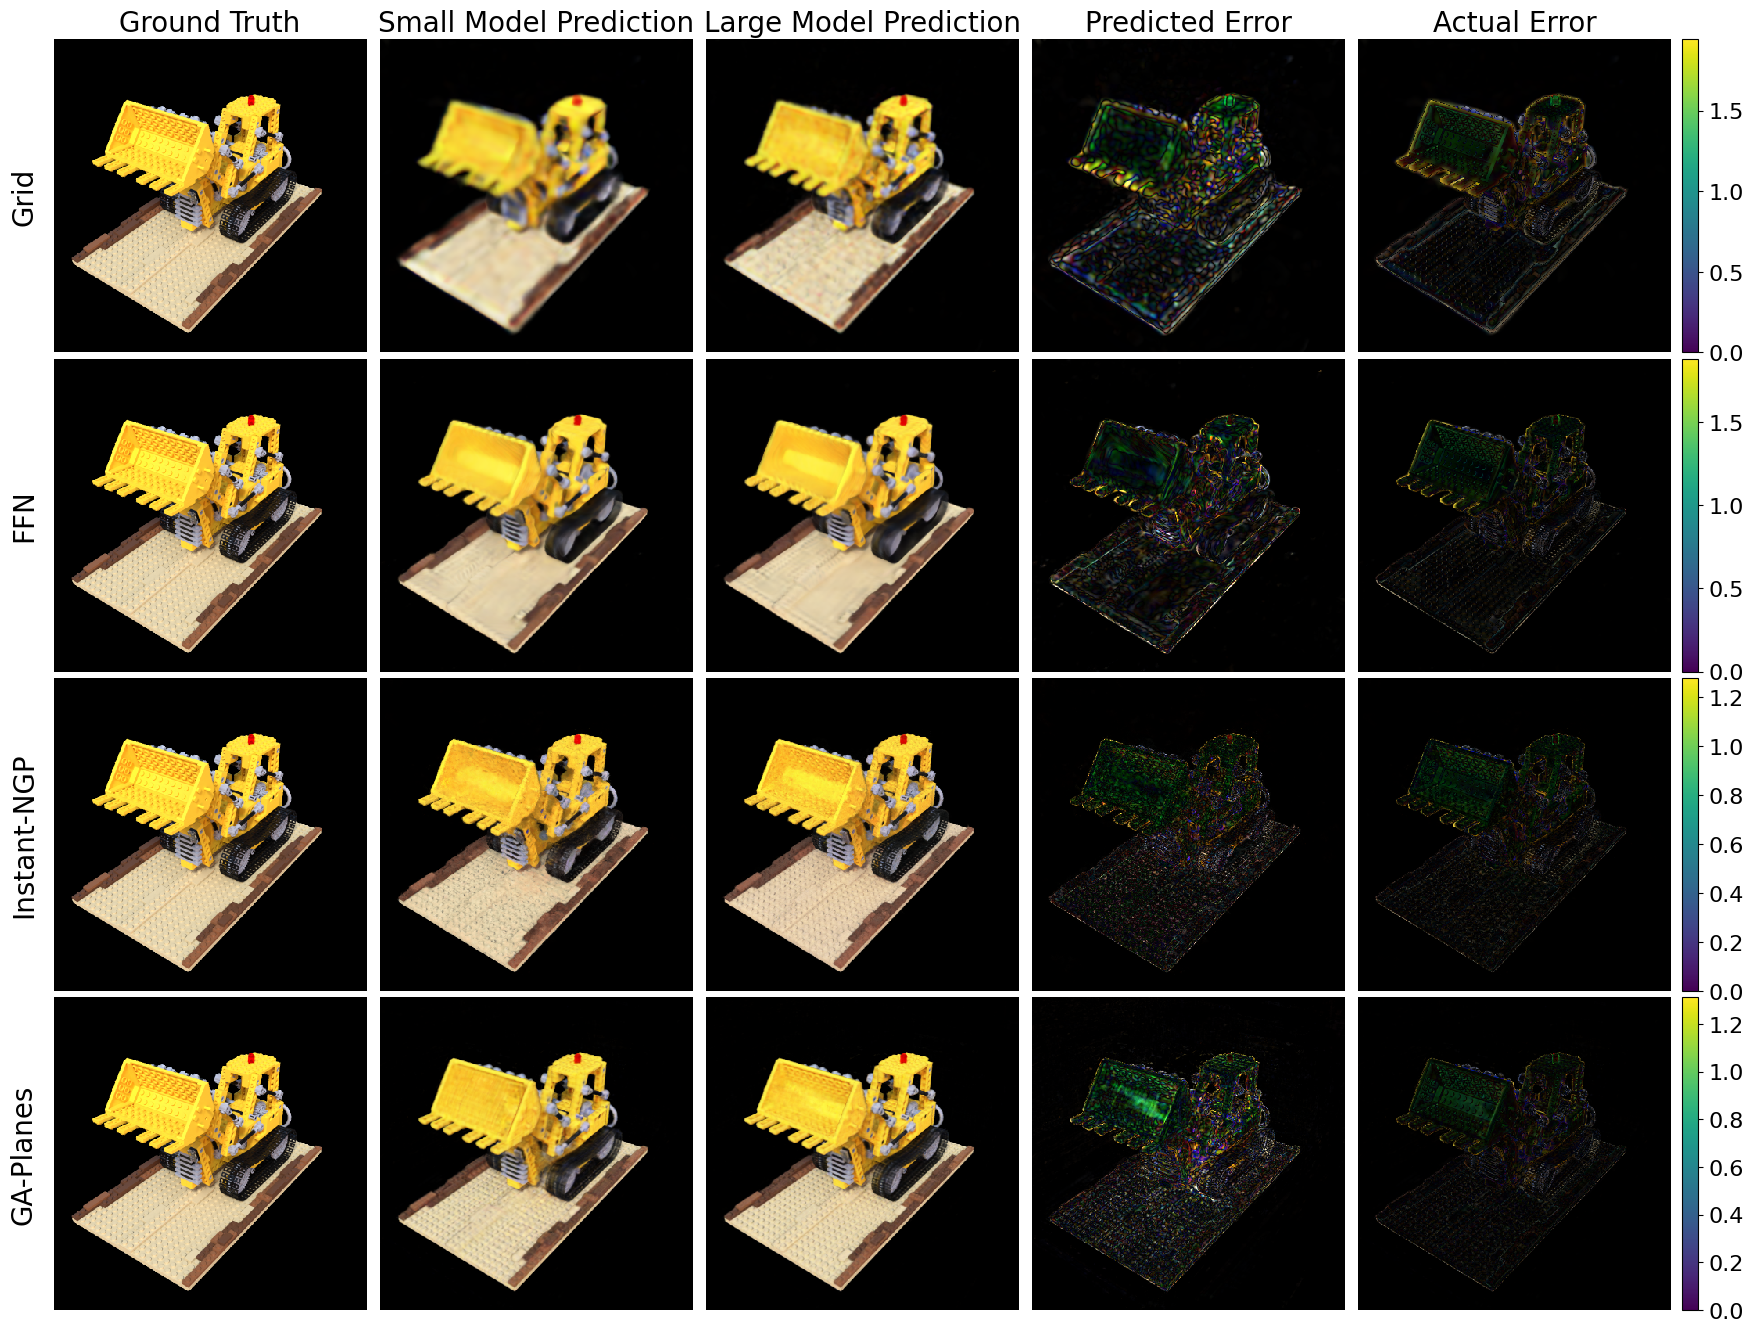

In [10]:
plot_error_heatmaps_fig('3d_nerf')

/tmp/ipykernel_1787772/2917671881.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0, 0.97, 1])


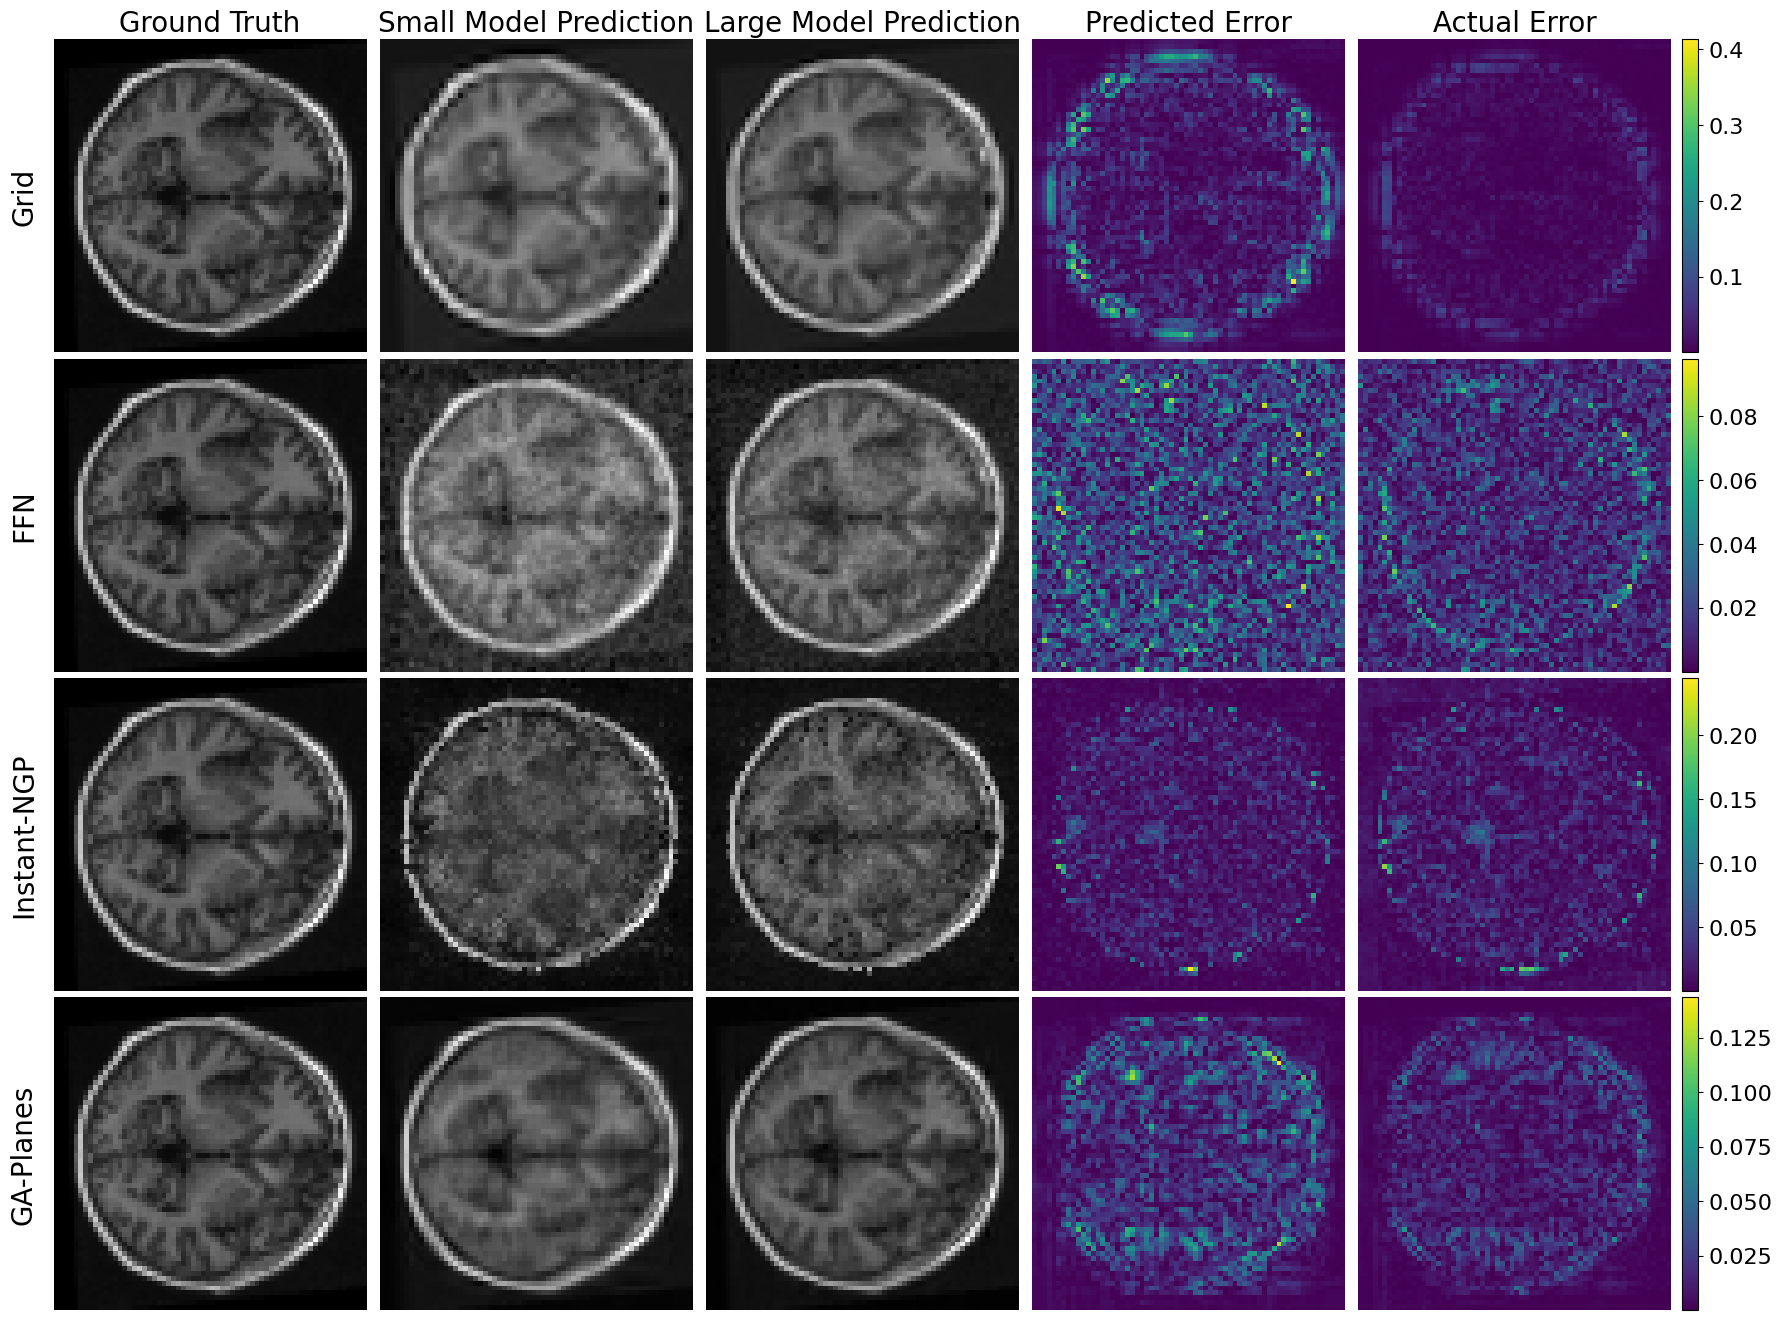

In [23]:
plot_error_heatmaps_fig('3d_mri')

/tmp/ipykernel_1000619/3562731147.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0, 0.97, 1])


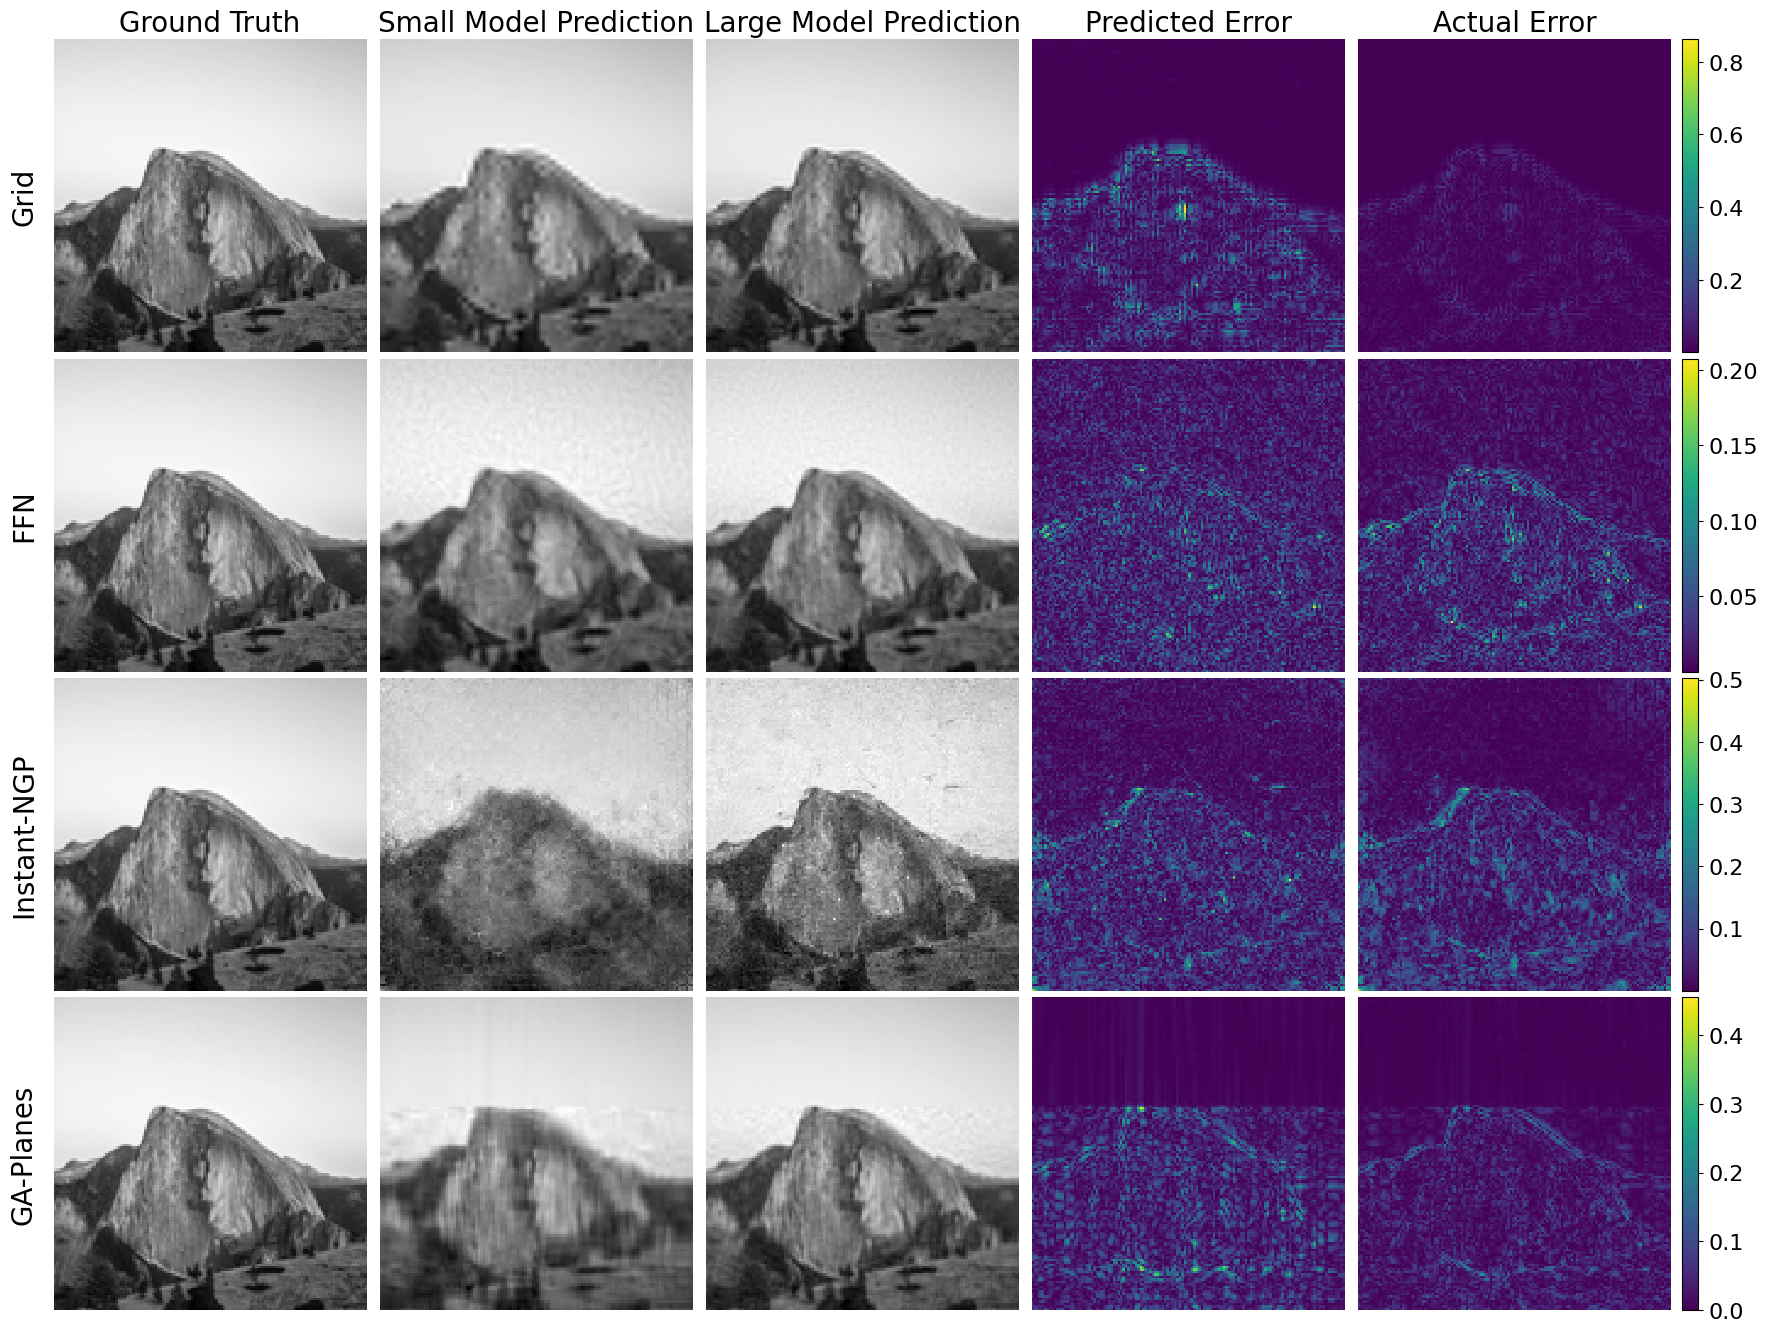

In [7]:
plot_error_heatmaps_fig('2d_div2k')

/tmp/ipykernel_1000619/2521769680.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0, 0.97, 1])


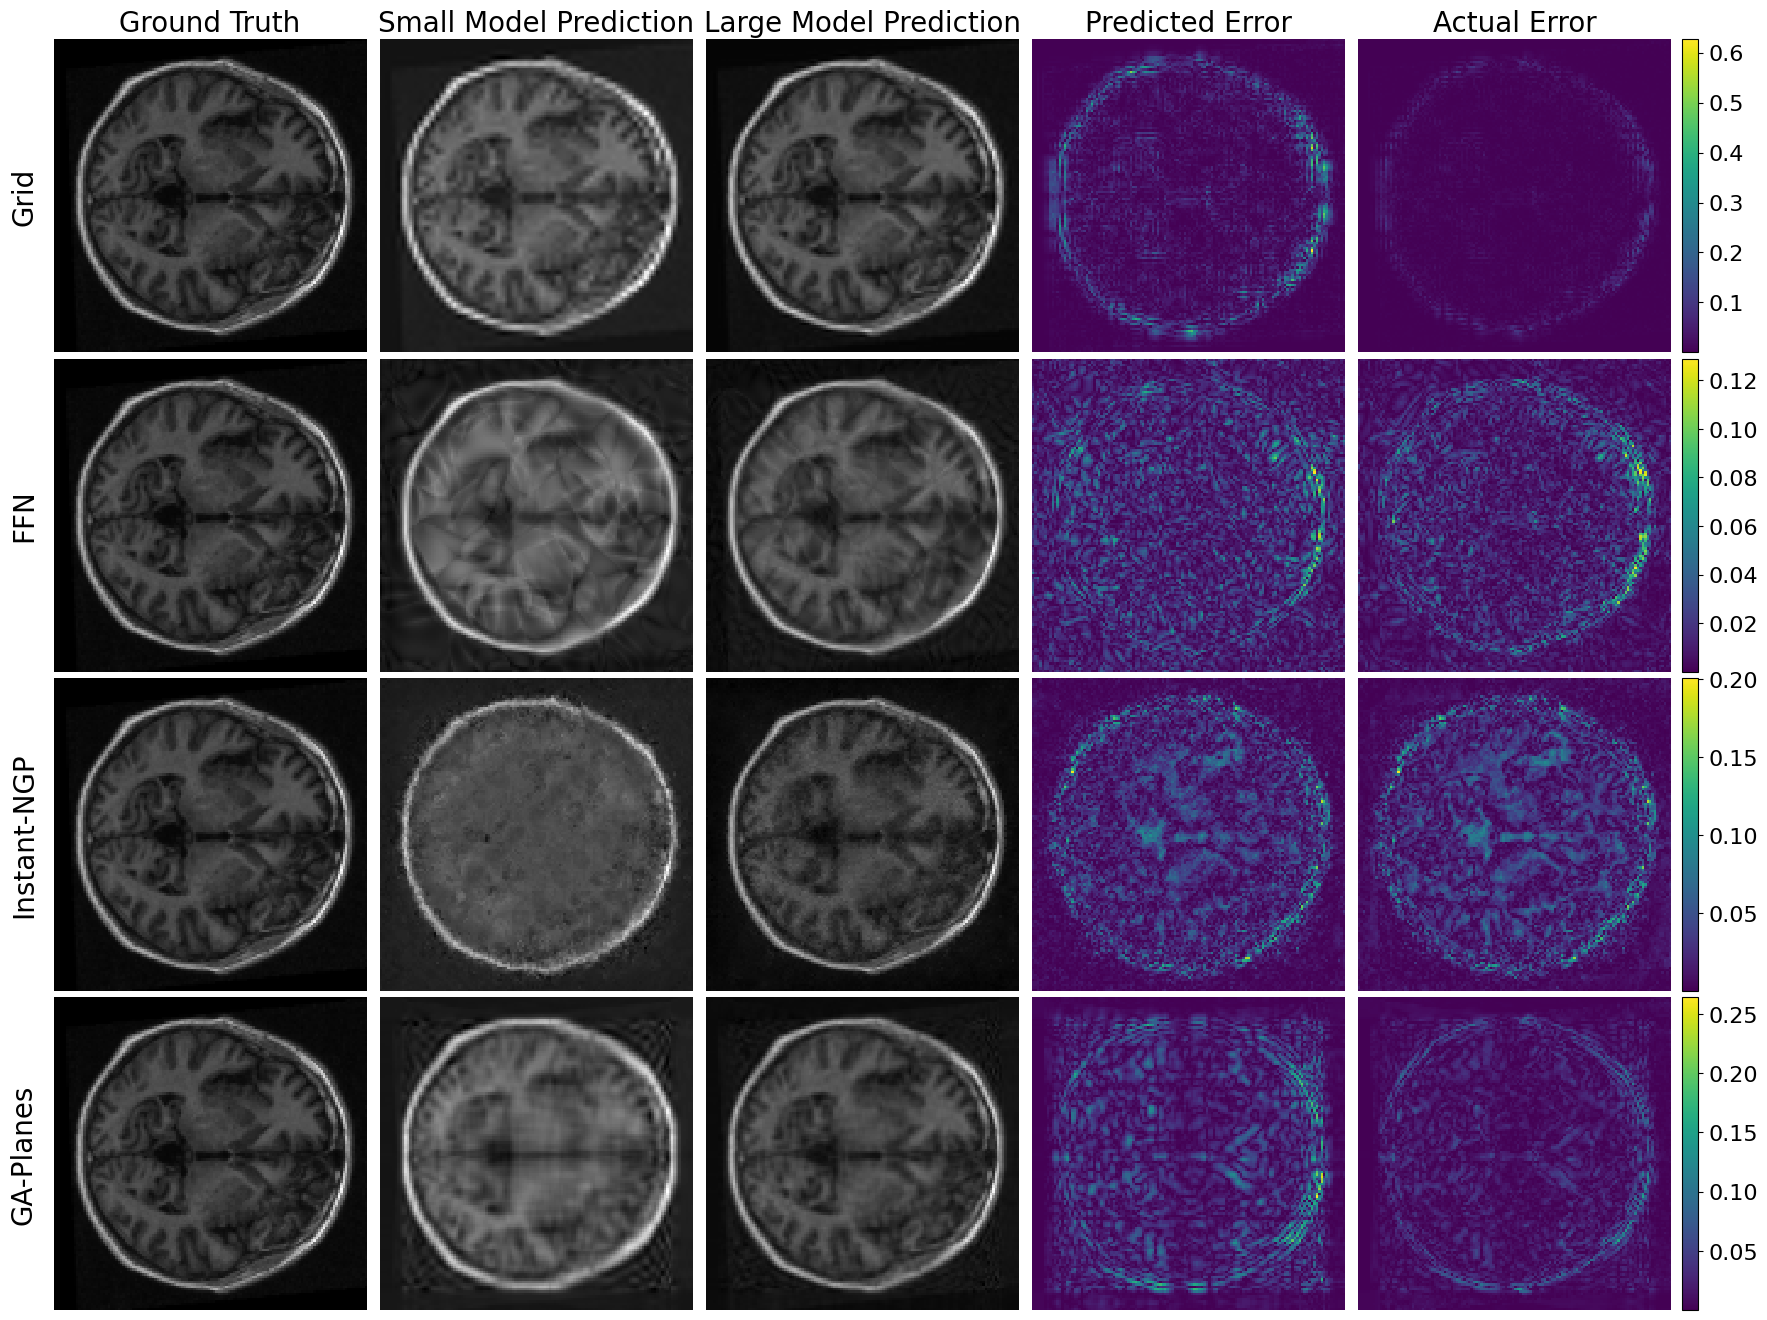

In [3]:
plot_error_heatmaps_fig('2d_mri')